# 10 統計的推定

### ライブラリのインポート

解析に必要なライブラリをインポートします。

| ライブラリ | 用途 |
|---|---|
| `numpy` | 数値計算・配列演算 |
| `pandas` | データフレーム操作 |
| `matplotlib` | グラフ描画 |
| `scipy.stats` | 確率分布・統計関数 |

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

%precision 3
%matplotlib inline

### データの読み込み

`ch4_scores400.csv` から400人分のテストスコアを読み込み、NumPy配列に変換します。  
この400個のデータ全体が本ノートブックにおける**母集団**として扱われます。

In [31]:
# データの読み込み(statistical_analysis_with_python/data/ch4_scores400.csv)
df = pd.read_csv('/home/jovyan/data/ch4_scores400.csv')
scores = np.array(df['点数'])

### 母平均・母分散の計算

母集団全体（$N=400$）の統計量を計算します。

$$
\mu = \frac{1}{N}\sum_{i=1}^{N} x_i, \qquad \sigma^2 = \frac{1}{N}\sum_{i=1}^{N}(x_i - \mu)^2
$$

これらは真の母数であり、以降の推定結果と比較する基準値として使用します。

In [32]:
p_mean = np.mean(scores)
p_var = np.var(scores)

p_mean, p_var

(69.530, 206.669)

### 母集団分布の可視化

母平均 $\mu$・母分散 $\sigma^2$ を持つ正規分布 $\mathcal{N}(\mu,\,\sigma^2)$ の確率密度関数と、  
実データのヒストグラムを重ねて描画します。

$$
f(x) = \frac{1}{\sqrt{2\pi\sigma^2}}\exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)
$$

データが正規分布にどの程度近いかを視覚的に確認します。

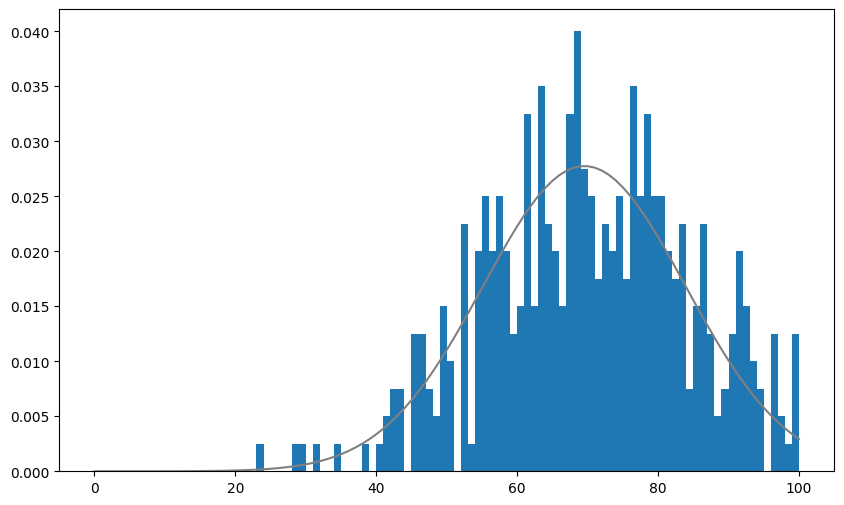

In [33]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

xs = np.arange(101)
rv = stats.norm(p_mean, np.sqrt(p_var))
ax.plot(xs, rv.pdf(xs), color='gray')
ax.hist(scores, bins=100, range=(0, 100), density=True)

plt.show()

### ランダムサンプリング（1回）

母集団からサイズ $n=20$ の標本を1組無作為抽出します。  
実際の統計調査では母集団全体を観測できないため、この標本から母数を推定します。

$$
\{x_1, x_2, \ldots, x_n\} \;\overset{\text{i.i.d.}}{\sim}\; \text{母集団},\quad n = 20
$$

In [34]:
np.random.seed(0)
n = 20
sample = np.random.choice(scores, n)
sample

array([49, 60, 72, 86, 52, 61, 77, 91, 80, 56, 69, 67, 90, 56, 75, 79, 60,
       79, 68, 81])

### 大量サンプリング（10,000回）

不偏性などの統計的性質をシミュレーションで検証するため、サイズ $n=20$ の標本を $B=10000$ 回繰り返し抽出します。

$$
\text{samples} \in \mathbb{R}^{B \times n}, \quad B = 10000,\; n = 20
$$

多数の標本から推定量の期待値を計算することで、その推定量が**不偏推定量**かどうかを確認できます。

In [35]:
np.random.seed(1111)
n_samples = 10000
samples = np.random.choice(scores, (n_samples, n))

## 10.1 点推定
### 10.1.1 母平均の点推定

#### 各標本の標本平均の確認

最初の5標本について標本平均を計算・表示します。

$$
\bar{x}^{(k)} = \frac{1}{n}\sum_{i=1}^{n} x_i^{(k)}, \quad k = 1, 2, 3, 4, 5
$$

標本ごとに異なる値になること（標本変動）を確認します。

In [36]:
for i in range(5):
    s_mean = np.mean(samples[i])
    print(f'{i+1}回目のサンプル平均: {s_mean:.3f}')

1回目のサンプル平均: 67.000
2回目のサンプル平均: 72.850
3回目のサンプル平均: 69.200
4回目のサンプル平均: 64.450
5回目のサンプル平均: 72.650


#### 標本平均の期待値（不偏性の確認）

$B=10000$ 個の標本平均の平均を計算し、母平均 $\mu$ に一致することを確認します（**標本平均の不偏性**）。

$$
\mathbb{E}[\bar{X}] = \mu
$$

$$
\frac{1}{B}\sum_{k=1}^{B}\bar{x}^{(k)} \approx \mu
$$

標本平均は母平均の不偏推定量であり、繰り返し推定すれば平均的に真の値に一致します。

In [37]:
sample_means = np.mean(samples, axis=1)
np.mean(sample_means)

69.538

#### 大標本による母平均の近似確認

サイズ $10^6$ の超大標本で標本平均を計算し、**大数の法則**を実演します。

$$
\bar{X}_n \xrightarrow{p} \mu \quad (n \to \infty)
$$

標本サイズが十分に大きくなると、標本平均は確率的に母平均に収束します。

In [38]:
np.mean(np.random.choice(scores, int(1e6)))

69.543

#### 元の標本による母平均の点推定

最初に抽出した $n=20$ の標本に対して標本平均（**点推定値**）を計算します。

$$
\hat{\mu} = \bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i
$$

点推定とは、1つの数値で母数を推定することです。

In [39]:
s_mean = np.mean(sample)
s_mean

70.400

### 10.1.2 簿分散の点推定

#### 各標本の標本分散の確認

最初の5標本について（**偏り付き**）標本分散を計算・表示します。

$$
s^2 = \frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2
$$

標本ごとに異なる値になること（標本変動）を確認します。

In [40]:
for i in range(5):
    s_var = np.var(samples[i])
    print(f'{i+1}回目のサンプル分散: {s_var:.3f}')

1回目のサンプル分散: 116.800
2回目のサンプル分散: 162.928
3回目のサンプル分散: 187.060
4回目のサンプル分散: 149.148
5回目のサンプル分散: 111.528


#### 標本分散の期待値（偏りの確認）

$B=10000$ 個の（偏り付き）標本分散の平均を計算します。  
標本分散の期待値は母分散 $\sigma^2$ より小さく、**過小推定**になることを確認します。

$$
\mathbb{E}[s^2] = \frac{n-1}{n}\,\sigma^2 \neq \sigma^2
$$

$n=20$ の場合、$\dfrac{n-1}{n} = \dfrac{19}{20} = 0.95$ となり、約5%過小推定されます。

In [41]:
sample_vars = np.var(samples, axis=1)
np.mean(sample_vars)

196.344

#### 不偏分散の期待値（不偏性の検証）

自由度補正 $\dfrac{1}{n-1}$ を用いた**不偏分散**の平均が母分散 $\sigma^2$ に一致することを確認します。

$$
U^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2, \qquad \mathbb{E}[U^2] = \sigma^2
$$

$\dfrac{1}{n-1}$ は、自由度 $n-1$ の補正により偏りをキャンセルします。

In [42]:
sample_u_vars = np.var(samples, axis=1, ddof=1)
np.mean(sample_u_vars)

206.678

#### 大標本による母分散の近似確認

サイズ $10^6$ の超大標本で不偏分散を計算し、母分散 $\sigma^2$ への収束を確認します。

$$
U^2_n \xrightarrow{p} \sigma^2 \quad (n \to \infty)
$$

In [43]:
np.var(np.random.choice(scores, int(1e6)), ddof=1)

207.083

#### 元の標本による母分散の点推定

最初に抽出した $n=20$ の標本に対して不偏分散（**点推定値**）を計算します。

$$
\hat{\sigma}^2 = U^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2
$$

`ddof=1`（degrees of freedom）が自由度補正 $\dfrac{1}{n-1}$ に対応します。

In [44]:
u_var = np.var(sample, ddof=1)
u_var

158.253

### 10.1.2 点推定のまとめ

## 10.2 区間推定
### 10.2.1 正規分布の母平均(分散既知)の区間推定

#### 母平均の信頼区間の計算（母分散既知）

母分散 $\sigma^2$ が既知のとき、標本平均 $\bar{X}$ を標準化した統計量は標準正規分布に従います。

$$
Z = \frac{\bar{X} - \mu}{\sigma/\sqrt{n}} \sim \mathcal{N}(0,\,1)
$$

有意水準 $\alpha=0.05$（信頼係数95%）の**両側信頼区間**は：

$$
\bar{x} - z_{0.025}\frac{\sigma}{\sqrt{n}} \;\leq\; \mu \;\leq\; \bar{x} + z_{0.025}\frac{\sigma}{\sqrt{n}}
$$

ここで $z_{0.025} = \Phi^{-1}(0.975) \approx 1.96$（標準正規分布の上側2.5%点）です。

In [60]:
rv = stats.norm()
lcl = s_mean - rv.ppf(0.975) * np.sqrt(p_var / n)
ucl = s_mean - rv.ppf(0.025) * np.sqrt(p_var / n)
lcl, ucl

(64.100, 76.700)

#### 信頼区間の可視化（20標本）

20個の異なる標本それぞれについて95%信頼区間を描画します。

- **灰色**：母平均 $\mu$ を含む区間
- **青色**：母平均 $\mu$ を含まない区間

区間推定の「95%」は、多数の標本から信頼区間を構成したとき、そのうち約95%が真の母平均を含むことを意味します（確率的解釈）。

/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 27597 (\N{CJK UNIFIED IDEOGRAPH-6BCD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


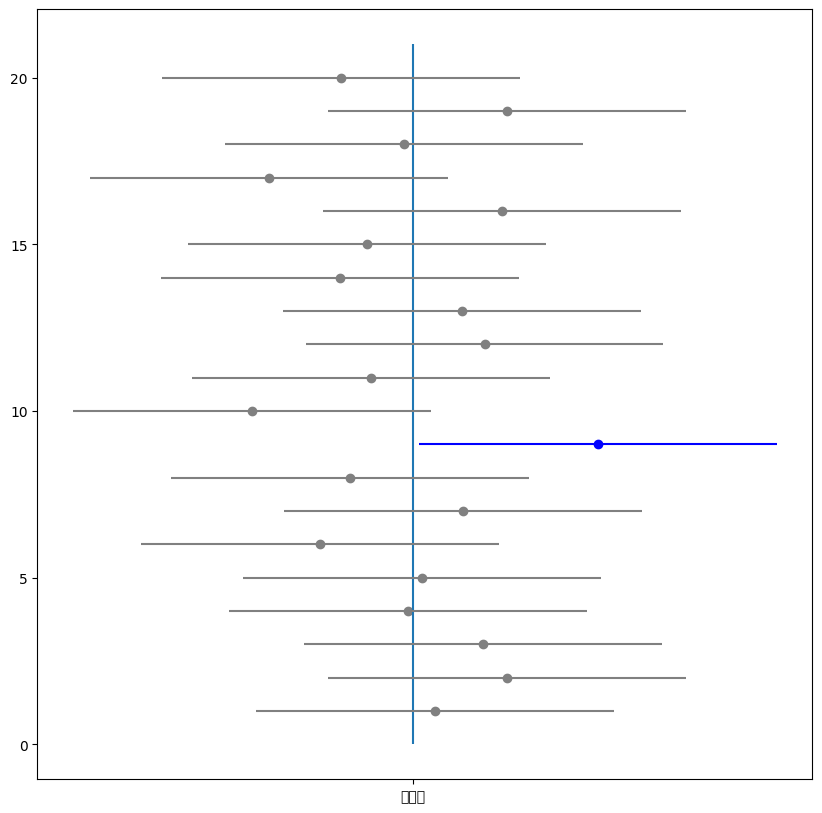

In [61]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)

rv = stats.norm()
n_samples = 20
ax.vlines(p_mean, 0, 21)
for i in range(n_samples):
    sample_ = samples[i]
    s_mean_ = np.mean(sample_)
    lcl = s_mean_ - rv.ppf(0.975) * np.sqrt(p_var / n)
    ucl = s_mean_ + rv.ppf(0.975) * np.sqrt(p_var / n)
    if lcl <= p_mean <= ucl:
        ax.scatter(s_mean_, n_samples - i, color='gray')
        ax.hlines(n_samples - i, lcl, ucl, color='gray')
    else:
        ax.scatter(s_mean_, n_samples - i, color='b')
        ax.hlines(n_samples - i, lcl, ucl, color='b')
ax.set_xticks([p_mean])
ax.set_xticklabels(['母平均'])

plt.show()

#### 被覆確率の検証（母平均・母分散既知）

$B=10000$ 個の標本すべてに対して信頼区間を構成し、母平均 $\mu$ を含む割合（**被覆確率**）が理論値 95% に一致することを検証します。

$$
\hat{p} = \frac{1}{B}\sum_{k=1}^{B}\mathbf{1}\!\left[\bar{x}^{(k)} - z_{0.025}\frac{\sigma}{\sqrt{n}} \;\leq\; \mu \;\leq\; \bar{x}^{(k)} + z_{0.025}\frac{\sigma}{\sqrt{n}}\right] \approx 0.95
$$

In [64]:
rv = stats.norm()
cnt = 0

for sample_ in samples:
    s_mean_ = np.mean(sample_)
    lcl = s_mean_ - rv.isf(0.025) * np.sqrt(p_var / n)
    ucl = s_mean_ - rv.isf(0.975) * np.sqrt(p_var / n)
    if lcl <= p_mean <= ucl:
        cnt += 1
cnt / len(samples)

0.951

### 10.2.2 正規分布の簿分散の区間推定

#### カイ二乗統計量への変換

不偏分散 $U^2$ を用いて構成した統計量は、自由度 $\nu = n-1$ の**カイ二乗分布**に従います。

$$
Y = \frac{(n-1)\,U^2}{\sigma^2} \sim \chi^2(n-1)
$$

各標本についてこの変換を適用し、理論分布との一致を確認します（次のセルで可視化）。

In [65]:
sample_y = sample_u_vars * (n - 1) / p_var
sample_y

array([11.303, 15.767, 18.102, ..., 19.435,  9.265, 18.625],
      shape=(10000,))

#### カイ二乗分布との比較

変換した統計量 $Y$ のヒストグラムと、理論的なカイ二乗分布 $\chi^2(n-1)$ の確率密度関数を重ねて描画します。

$$
f(x;\,\nu) = \frac{x^{\nu/2-1}\,e^{-x/2}}{2^{\nu/2}\,\Gamma(\nu/2)},\quad x > 0,\quad \nu = n-1 = 19
$$

ヒストグラムと理論曲線が一致することで、$\chi^2$ 分布への従属が確認できます。

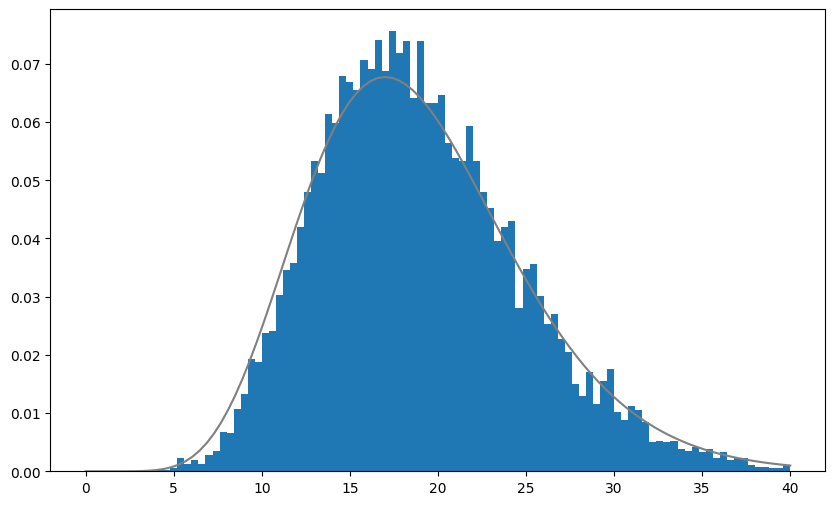

In [66]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

xs  = np.linspace(0, 40, 100)
rv = stats.chi2(df = n - 1)
ax.plot(xs, rv.pdf(xs), color='gray')
hist, _, _ = ax.hist(sample_y, bins=100, range=(0, 40), density=True)

plt.show()

#### 母分散の信頼区間の計算

カイ二乗分布の上側確率点を用いて母分散 $\sigma^2$ の95%信頼区間を構成します。

$$
P\!\left(\chi^2_{0.975}(n-1) \leq \frac{(n-1)U^2}{\sigma^2} \leq \chi^2_{0.025}(n-1)\right) = 0.95
$$

これを $\sigma^2$ について整理すると：

$$
\frac{(n-1)\,U^2}{\chi^2_{0.025}(n-1)} \;\leq\; \sigma^2 \;\leq\; \frac{(n-1)\,U^2}{\chi^2_{0.975}(n-1)}
$$

In [67]:
rv = stats.chi2(df = n - 1)
lcl = (n - 1) * u_var / rv.isf(0.025)
hcl = (n - 1) * u_var / rv.isf(0.975)

lcl, hcl

(91.525, 337.596)

#### 母分散の信頼区間の可視化（20標本）

20個の標本それぞれについて母分散の95%信頼区間を描画します。

- **灰色**：母分散 $\sigma^2$ を含む区間
- **青色**：母分散 $\sigma^2$ を含まない区間

カイ二乗分布は非対称のため、信頼区間の幅は平均値を中心にした対称な形になりません。

/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 27597 (\N{CJK UNIFIED IDEOGRAPH-6BCD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 25955 (\N{CJK UNIFIED IDEOGRAPH-6563}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


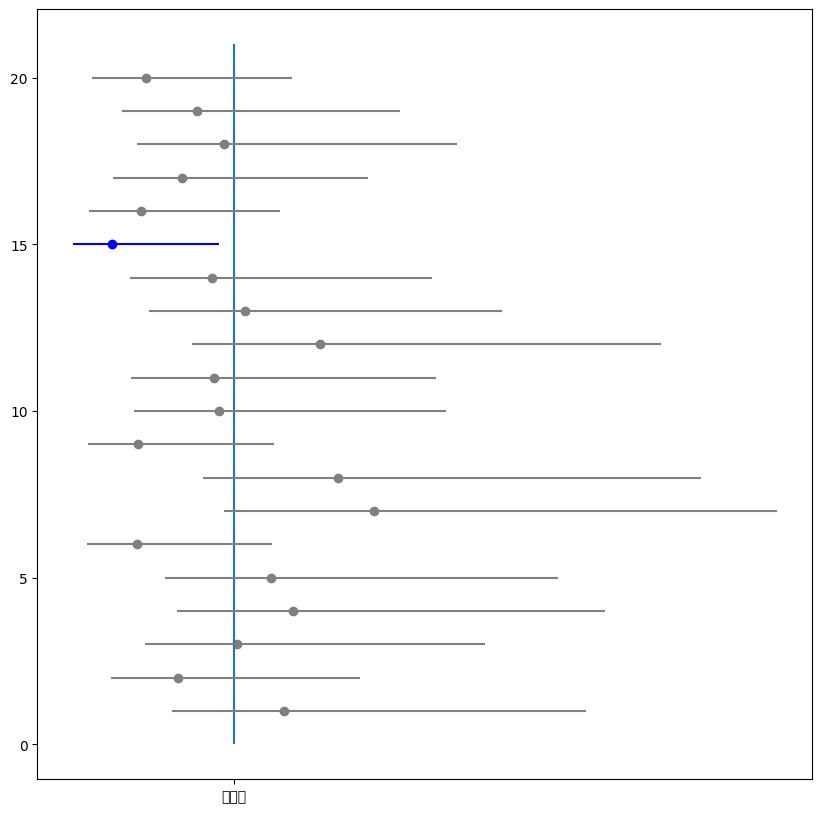

In [68]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)

rv = stats.chi2(df = n - 1)
n_samples = 20
ax.vlines(p_var, 0, 21)
for i in range(n_samples):
    sample_ = samples[i]
    u_var_ = np.var(sample_, ddof=1)
    lcl = (n - 1) * u_var_ / rv.isf(0.025)
    hcl = (n - 1) * u_var_ / rv.isf(0.975)
    if lcl <= p_var <= hcl:
        ax.scatter(u_var_, n_samples - i, color='gray')
        ax.hlines(n_samples - i, lcl, hcl, color='gray')
    else:
        ax.scatter(u_var_, n_samples - i, color='b')
        ax.hlines(n_samples - i, lcl, hcl, color='b')
ax.set_xticks([p_var])
ax.set_xticklabels(['母分散'])

plt.show()

#### 母分散信頼区間の被覆確率の検証

$B=10000$ 個の標本すべてで母分散の信頼区間を構成し、被覆確率が理論値 95% に一致することを確認します。

$$
\hat{p} = \frac{1}{B}\sum_{k=1}^{B}\mathbf{1}\!\left[\frac{(n-1)\,U^{2(k)}}{\chi^2_{0.025}} \;\leq\; \sigma^2 \;\leq\; \frac{(n-1)\,U^{2(k)}}{\chi^2_{0.975}}\right] \approx 0.95
$$

In [69]:
rv = stats.chi2(df = n - 1)
cnt = 0
for sample_ in samples:
    u_var_ = np.var(sample_, ddof=1)
    lcl = (n - 1) * u_var_ / rv.isf(0.025)
    hcl = (n - 1) * u_var_ / rv.isf(0.975)
    if lcl <= p_var <= hcl:
        cnt += 1
cnt / len(samples)

0.964

### 10.2.3 正規分布の母平均(母分散未知)の区間推定

#### t分布による母平均の信頼区間（母分散未知）

母分散 $\sigma^2$ が未知のとき、不偏分散 $U^2$ で代替した統計量は自由度 $\nu = n-1$ の**t分布**に従います。

$$
T = \frac{\bar{X} - \mu}{U/\sqrt{n}} \sim t(n-1)
$$

95%信頼区間は：

$$
\bar{x} - t_{0.025}(n-1)\frac{U}{\sqrt{n}} \;\leq\; \mu \;\leq\; \bar{x} + t_{0.025}(n-1)\frac{U}{\sqrt{n}}
$$

t分布は正規分布より裾が厚いため、母分散既知の場合（正規分布使用）より信頼区間の幅が広くなります。

In [72]:
rv = stats.t(df = n - 1)
lcl = s_mean - rv.isf(0.025) * np.sqrt(u_var / n)
ucl = s_mean - rv.isf(0.975) * np.sqrt(u_var / n)

lcl, ucl

(64.512, 76.288)

### 10.2.4 ベルヌーイ分布の母平均の区間推定

#### アンケートデータの読み込み

`ch10_enquete.csv` から二値（0/1）のアンケートデータを読み込みます。  
各観測値は**ベルヌーイ分布**に従い、母比率 $p$（既知の割合）を推定します。

$$
X_i \sim \text{Bernoulli}(p),\quad X_i \in \{0, 1\}
$$

In [73]:
# statistical_analysis_with_python/data/ch10_enquete.csv
enqute_df = pd.read_csv('/home/jovyan/data/ch10_enquete.csv')
enqute = np.array(enqute_df['知っている'])
n = len(enqute)
enqute[:10]

array([1, 0, 1, 1, 1, 1, 1, 0, 0, 1])

#### 標本比率の計算

0/1データの標本平均は、母比率 $p$ の点推定値（**標本比率**）となります。

$$
\hat{p} = \bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i = \frac{\text{（1の個数）}}{n}
$$

In [74]:
s_mean = enqute.mean()
s_mean

0.709

#### ベルヌーイ分布の母比率の信頼区間

大標本では、**中心極限定理**により標本比率 $\hat{p}$ は正規分布で近似できます。  
ベルヌーイ分布の分散は $p(1-p)$ のため：

$$
\frac{\hat{p} - p}{\sqrt{\hat{p}(1-\hat{p})/n}} \;\xrightarrow{d}\; \mathcal{N}(0,\,1)
$$

95%信頼区間（母比率 $p$ を $\hat{p}$ で代入）：

$$
\hat{p} - z_{0.025}\sqrt{\frac{\hat{p}(1-\hat{p})}{n}} \;\leq\; p \;\leq\; \hat{p} + z_{0.025}\sqrt{\frac{\hat{p}(1-\hat{p})}{n}}
$$

In [76]:
rv = stats.norm()
lcl = s_mean - rv.isf(0.025) * np.sqrt(s_mean * (1 - s_mean) / n)
ucl = s_mean - rv.isf(0.975) * np.sqrt(s_mean * (1 - s_mean) / n)

lcl, ucl

(0.681, 0.737)

### 10.2.5 ポアソン分布の母平均の信頼区間

#### アクセスデータの読み込み

`ch10_access.csv` からウェブサイトへの日別アクセス数データを読み込みます。  
アクセス数は**ポアソン分布**に従うと仮定します。

$$
X_i \sim \text{Poisson}(\lambda),\quad X_i \in \{0,\,1,\,2,\,\ldots\}
$$

ポアソン分布の確率質量関数：$P(X=k) = \dfrac{\lambda^k e^{-\lambda}}{k!}$

In [77]:
n_access_df = pd.read_csv('/home/jovyan/data/ch10_access.csv')
n_access = np.array(n_access_df['アクセス数'])
n = len(n_access)
n_access[:10] 

array([10, 11,  9,  9, 18, 13,  4, 10, 10,  8])

#### 標本平均の計算（ポアソン分布の点推定）

ポアソン分布の発生率パラメータ $\lambda$ を標本平均で点推定します。

$$
\hat{\lambda} = \bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i
$$

ポアソン分布では平均と分散が一致します（$\mathbb{E}[X] = \text{Var}[X] = \lambda$）。  
この性質を次の信頼区間の構成に利用します。

In [78]:
s_mean = n_access.mean()
s_mean

10.444

#### ポアソン分布の母平均の信頼区間

大標本では、**中心極限定理**によりポアソン分布の標本平均は正規分布で近似できます。  
$\text{Var}[X_i] = \lambda$ を $\hat{\lambda} = \bar{x}$ で推定するため：

$$
\frac{\bar{X} - \lambda}{\sqrt{\lambda/n}} \;\xrightarrow{d}\; \mathcal{N}(0,\,1)
$$

95%信頼区間（$\lambda$ を $\hat{\lambda} = \bar{x}$ で代入）：

$$
\bar{x} - z_{0.025}\sqrt{\frac{\bar{x}}{n}} \;\leq\; \lambda \;\leq\; \bar{x} + z_{0.025}\sqrt{\frac{\bar{x}}{n}}
$$

In [79]:
rv  = stats.norm()
lcl = s_mean - rv.isf(0.025) * np.sqrt(s_mean / n)
ucl = s_mean - rv.isf(0.975) * np.sqrt(s_mean / n)
lcl, ucl

(9.698, 11.191)